#📌 Extracción

In [1]:
# Importar las librerías necesarias
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re # Para trabajar con expresiones regulares, útil en limpieza

# Configurar visualizaciones
plt.style.use('ggplot')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None) # Mostrar todas las columnas

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [3]:
# Cargar los datos desde el archivo JSON
# Nota: Ajusta la ruta si el archivo no está en el mismo directorio.
# En Colab, necesitarías subir el archivo primero.
try:
    with open('TelecomX_Data.json', 'r') as archivo:
        datos_json = json.load(archivo)
    print("Datos JSON cargados exitosamente.")
except FileNotFoundError:
    print("Error: No se encontró el archivo 'TelecomX_Data.json'.")
    print("Asegúrate de que el archivo esté en el directorio correcto.")
    # En un entorno de notebook, podríamos detener la ejecución aquí,
    # pero para seguir la guía, asumiremos que se cargó correctamente.
    # Usaremos una lista vacía para evitar errores posteriores.
    datos_json = []

Datos JSON cargados exitosamente.


In [4]:
# Convertir la lista de diccionarios a un DataFrame de Pandas
df = pd.json_normalize(datos_json) # json_normalize aplana la estructura anidada como 'customer' y 'account'
print("Datos convertidos a DataFrame.")
print(f"El DataFrame tiene {df.shape[0]} filas y {df.shape[1]} columnas.")

Datos convertidos a DataFrame.
El DataFrame tiene 7267 filas y 21 columnas.


In [5]:
# Ver las primeras filas para confirmar la estructura
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

In [6]:
# Información general del DataFrame
print("=== Información del DataFrame ===")
df.info()

print("\n=== Tipos de Datos ===")
print(df.dtypes)

print("\n=== Estadísticas Descriptivas (Columnas Numéricas) ===")
# Seleccionar solo columnas numéricas para describe
df.describe()

=== Información del DataFrame ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechS

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


In [7]:
# --- Valores Ausentes ---
print("=== Valores Ausentes por Columna ===")
# Contar valores nulos (NaN) en cada columna
valores_ausentes = df.isnull().sum()
print(valores_ausentes[valores_ausentes > 0]) # Mostrar solo columnas con ausentes

print("\n--- Revisión de valores vacíos o con espacios en 'Churn' y 'Total Charges' ---")
# Buscar cadenas vacías o que solo contengan espacios, que Pandas no detecta como NaN
for col in ['Churn', 'account.Charges.Total']:
    if col in df.columns:
        # Cuenta las veces que el valor es una cadena vacía o solo espacios
        # Convertimos a string por si acaso, y luego aplicamos strip
        count_empty_str = df[col].astype(str).str.strip().eq('').sum()
        if count_empty_str > 0:
            print(f"Columna '{col}': {count_empty_str} valores son cadenas vacías o solo espacios.")
        else:
            print(f"Columna '{col}': No se encontraron cadenas vacías.")

# --- Valores Duplicados ---
print("\n=== Valores Duplicados ===")
duplicados = df.duplicated().sum()
print(f"Número de filas duplicadas: {duplicados}")
if duplicados > 0:
    print("Mostrando filas duplicadas:")
    df[df.duplicated(keep=False)].sort_values(by='customerID') # keep=False muestra todas las ocurrencias

# --- Revisión de Consistencia en Categorías ---
print("\n=== Revisión de Categorías en Columnas Clave ===")
columnas_categoricas = ['Churn', 'customer.gender', 'customer.Partner', 'customer.Dependents',
                        'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
                        'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection',
                        'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies',
                        'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod']

for col in columnas_categoricas:
    if col in df.columns:
        print(f"\nCategorías en '{col}':")
        print(df[col].value_counts(dropna=False))
    else:
        print(f"Columna '{col}' no encontrada.")

=== Valores Ausentes por Columna ===
Series([], dtype: int64)

--- Revisión de valores vacíos o con espacios en 'Churn' y 'Total Charges' ---
Columna 'Churn': 224 valores son cadenas vacías o solo espacios.
Columna 'account.Charges.Total': 11 valores son cadenas vacías o solo espacios.

=== Valores Duplicados ===
Número de filas duplicadas: 0

=== Revisión de Categorías en Columnas Clave ===

Categorías en 'Churn':
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

Categorías en 'customer.gender':
customer.gender
Male      3675
Female    3592
Name: count, dtype: int64

Categorías en 'customer.Partner':
customer.Partner
No     3749
Yes    3518
Name: count, dtype: int64

Categorías en 'customer.Dependents':
customer.Dependents
No     5086
Yes    2181
Name: count, dtype: int64

Categorías en 'phone.PhoneService':
phone.PhoneService
Yes    6560
No      707
Name: count, dtype: int64

Categorías en 'phone.MultipleLines':
phone.MultipleLines
No                  3495
Yes     

In [8]:
print("--- Iniciando limpieza de datos ---")
df_limpio = df.copy() # Trabajar sobre una copia para no modificar el original

# --- 1. Limpiar 'Churn' ---
# Reemplazar cadenas vacías por NaN y luego eliminar filas con Churn nulo
print(f"Filas antes de limpiar Churn: {df_limpio.shape[0]}")
df_limpio['Churn'] = df_limpio['Churn'].replace(r'^\s*$', np.nan, regex=True) # Convierte cadenas vacías o solo espacios en NaN
df_limpio.dropna(subset=['Churn'], inplace=True)
print(f"Filas después de eliminar Churn vacío: {df_limpio.shape[0]}")

# --- 2. Limpiar 'account.Charges.Total' ---
# Primero, reemplazar los espacios en blanco con NaN y luego convertir a numérico
print(f"\nValores únicos en 'Total Charges' antes de limpiar: {df_limpio['account.Charges.Total'].unique()[:10]}...") # Mostrar algunos
df_limpio['account.Charges.Total'] = df_limpio['account.Charges.Total'].replace(r'^\s*$', np.nan, regex=True)
df_limpio['account.Charges.Total'] = pd.to_numeric(df_limpio['account.Charges.Total'], errors='coerce')

# Verificar cuántos NaN resultaron de la conversión
total_nan_despues = df_limpio['account.Charges.Total'].isnull().sum()
print(f"Número de valores NaN en 'Total Charges' después de conversión: {total_nan_despues}")

# --- 3. Tratar los nuevos NaN en 'Total Charges' ---
# Opción A: Eliminar filas con Total Charges NaN (son pocas)
# Opción B: Imputar. Dado que tenemos 'tenure' y 'Monthly Charges', podemos calcular una aproximación.
# Total = Monthly * tenure. Usaremos esta lógica para imputar, ya que es más precisa.
for index in df_limpio[df_limpio['account.Charges.Total'].isnull()].index:
    monthly = df_limpio.loc[index, 'account.Charges.Monthly']
    tenure = df_limpio.loc[index, 'customer.tenure']
    if pd.notna(monthly) and pd.notna(tenure) and tenure > 0:
        total_calculado = monthly * tenure
        df_limpio.loc[index, 'account.Charges.Total'] = total_calculado
        print(f"Filas con Total Charges imputado: {index}, ID: {df_limpio.loc[index, 'customerID']}, Nuevo Total: {total_calculado:.2f}")
    else:
        # Si no podemos calcularlo (por ejemplo, tenure=0), lo dejamos como NaN o lo imputamos con 0?
        # Lo dejaremos como NaN por ahora y decidiremos después.
        print(f"Filas con Total Charges NO imputado (tenure o monthly inválidos): {index}")

# Después de la imputación, ver si quedan NaN
nan_restantes = df_limpio['account.Charges.Total'].isnull().sum()
print(f"\nValores NaN en 'Total Charges' después de imputación: {nan_restantes}")
# Si aún quedan (por ejemplo, con tenure=0), los eliminaremos.
df_limpio.dropna(subset=['account.Charges.Total'], inplace=True)
print(f"Filas después de eliminar Total Charges NaN restantes: {df_limpio.shape[0]}")

print("\n--- Limpieza completada ---")

--- Iniciando limpieza de datos ---
Filas antes de limpiar Churn: 7267
Filas después de eliminar Churn vacío: 7043

Valores únicos en 'Total Charges' antes de limpiar: ['593.3' '542.4' '280.85' '1237.85' '267.4' '571.45' '7904.25' '5377.8'
 '340.35' '5957.9']...
Número de valores NaN en 'Total Charges' después de conversión: 11
Filas con Total Charges NO imputado (tenure o monthly inválidos): 975
Filas con Total Charges NO imputado (tenure o monthly inválidos): 1775
Filas con Total Charges NO imputado (tenure o monthly inválidos): 1955
Filas con Total Charges NO imputado (tenure o monthly inválidos): 2075
Filas con Total Charges NO imputado (tenure o monthly inválidos): 2232
Filas con Total Charges NO imputado (tenure o monthly inválidos): 2308
Filas con Total Charges NO imputado (tenure o monthly inválidos): 2930
Filas con Total Charges NO imputado (tenure o monthly inválidos): 3134
Filas con Total Charges NO imputado (tenure o monthly inválidos): 3203
Filas con Total Charges NO imput

In [9]:
# Verificar los tipos de datos después de la limpieza
print("=== Tipos de Datos después de la Limpieza ===")
print(df_limpio.dtypes)

# Verificar que no queden valores problemáticos en Churn y Total Charges
print(f"\nValores únicos en 'Churn': {df_limpio['Churn'].unique()}")
print(f"Tipo de dato de 'Total Charges': {df_limpio['account.Charges.Total'].dtype}")

=== Tipos de Datos después de la Limpieza ===
customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner              object
customer.Dependents           object
customer.tenure                int64
phone.PhoneService            object
phone.MultipleLines           object
internet.InternetService      object
internet.OnlineSecurity       object
internet.OnlineBackup         object
internet.DeviceProtection     object
internet.TechSupport          object
internet.StreamingTV          object
internet.StreamingMovies      object
account.Contract              object
account.PaperlessBilling      object
account.PaymentMethod         object
account.Charges.Monthly      float64
account.Charges.Total        float64
dtype: object

Valores únicos en 'Churn': ['No' 'Yes']
Tipo de dato de 'Total Charges': float64


#📊 Carga y análisis

In [10]:
# Crear la columna 'Cuentas_Diarias' (Cargo Diario Promedio)
# Asumimos un mes de 30 días para simplificar.
df_limpio['Cuentas_Diarias'] = df_limpio['account.Charges.Monthly'] / 30

print("Columna 'Cuentas_Diarias' creada (Cargo Mensual / 30).")
print(df_limpio[['account.Charges.Monthly', 'Cuentas_Diarias']].head())

Columna 'Cuentas_Diarias' creada (Cargo Mensual / 30).
   account.Charges.Monthly  Cuentas_Diarias
0                     65.6         2.186667
1                     59.9         1.996667
2                     73.9         2.463333
3                     98.0         3.266667
4                     83.9         2.796667


In [11]:
print("--- Iniciando estandarización ---")
df_final = df_limpio.copy()

# --- Traducción y Renombre de Columnas ---
# Crear un nuevo DataFrame con nombres de columnas en español para facilitar el análisis
df_final.rename(columns={
    'customerID': 'ID_Cliente',
    'Churn': 'Evasión',
    'customer.gender': 'Género',
    'customer.SeniorCitizen': 'Adulto_Mayor',
    'customer.Partner': 'Pareja',
    'customer.Dependents': 'Dependientes',
    'customer.tenure': 'Antigüedad_meses',
    'phone.PhoneService': 'Servicio_Teléfono',
    'phone.MultipleLines': 'Múltiples_Líneas',
    'internet.InternetService': 'Servicio_Internet',
    'internet.OnlineSecurity': 'Seguridad_Online',
    'internet.OnlineBackup': 'Backup_Online',
    'internet.DeviceProtection': 'Protección_Dispositivo',
    'internet.TechSupport': 'Soporte_Técnico',
    'internet.StreamingTV': 'Streaming_TV',
    'internet.StreamingMovies': 'Streaming_Películas',
    'account.Contract': 'Tipo_Contrato',
    'account.PaperlessBilling': 'Factura_Sin_Papel',
    'account.PaymentMethod': 'Método_Pago',
    'account.Charges.Monthly': 'Cargo_Mensual',
    'account.Charges.Total': 'Cargo_Total'
}, inplace=True)

print("Columnas renombradas al español.")

# --- Transformación de Valores a Binario (1/0) para columnas Sí/No ---
# Lista de columnas que son claramente Sí/No (o similares)
columnas_si_no = ['Adulto_Mayor', 'Pareja', 'Dependientes', 'Servicio_Teléfono',
                  'Factura_Sin_Papel', 'Evasión'] # Evasión también es Sí/No

# Añadir las columnas de servicios adicionales de internet que son 'Yes'/'No'/'No service'
# Para estas, primero manejaremos el 'No internet service' y luego mapearemos 'Yes'/'No'
columnas_servicios_internet = ['Seguridad_Online', 'Backup_Online', 'Protección_Dispositivo',
                                'Soporte_Técnico', 'Streaming_TV', 'Streaming_Películas']

for col in columnas_si_no:
    if col in df_final.columns:
        # Mapear 'Yes' a 1, 'No' a 0. Asumimos que no hay otros valores.
        df_final[col] = df_final[col].map({'Yes': 1, 'No': 0, 'Female': 1, 'Male': 0}) # Para género, mapeamos Female a 1, Male a 0
        # Para Adulto_Mayor, ya es 0/1, así que el map no hará nada si no es 'Yes'/'No', pero lo dejamos por seguridad.
        # En caso de que ya sea numérico, el map devolverá NaN, así que mejor lo hacemos condicional.
        if df_final[col].dtype == 'object':
             df_final[col] = df_final[col].map({'Yes': 1, 'No': 0, 'Female': 1, 'Male': 0})

print("Columnas Sí/No mapeadas a 1/0 (o NaN si no se pudo mapear).")

# Para las columnas de servicios de internet, primero homogenizamos la negativa.
for col in columnas_servicios_internet:
    if col in df_final.columns:
        # Reemplazar 'No internet service' por 'No' para simplificar
        df_final[col] = df_final[col].replace('No internet service', 'No')
        # Luego convertir 'Yes' a 1 y 'No' a 0
        df_final[col] = df_final[col].map({'Yes': 1, 'No': 0})

print("Servicios de internet estandarizados a 1/0.")

# Columna 'Múltiples_Líneas' tiene 'Yes', 'No', 'No phone service'
df_final['Múltiples_Líneas'] = df_final['Múltiples_Líneas'].replace('No phone service', 'No')
df_final['Múltiples_Líneas'] = df_final['Múltiples_Líneas'].map({'Yes': 1, 'No': 0})
print("Múltiples Líneas estandarizado.")

# --- Verificación de la transformación ---
print("\nPrimeras filas después de la estandarización:")
df_final.head()

--- Iniciando estandarización ---
Columnas renombradas al español.
Columnas Sí/No mapeadas a 1/0 (o NaN si no se pudo mapear).
Servicios de internet estandarizados a 1/0.
Múltiples Líneas estandarizado.

Primeras filas después de la estandarización:


,ID_Cliente,Evasión,Género,Adulto_Mayor,Pareja,Dependientes,Antigüedad_meses,Servicio_Teléfono,Múltiples_Líneas,Servicio_Internet,Seguridad_Online,Backup_Online,Protección_Dispositivo,Soporte_Técnico,Streaming_TV,Streaming_Películas,Tipo_Contrato,Factura_Sin_Papel,Método_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,NaN,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,NaN,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,NaN,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,NaN,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,NaN,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [12]:
print("=== Análisis Descriptivo de Variables Numéricas (Agrupado por Evasión) ===")
# Seleccionar columnas numéricas para el análisis
columnas_numericas = ['Adulto_Mayor', 'Antigüedad_meses', 'Cargo_Mensual', 'Cargo_Total', 'Cuentas_Diarias'] + columnas_si_no[1:-1] + columnas_servicios_internet + ['Múltiples_Líneas']
# Asegurarse de que las columnas existen
columnas_numericas_existentes = [col for col in columnas_numericas if col in df_final.columns]

df_final.groupby('Evasión')[columnas_numericas_existentes].agg(['mean', 'median', 'std', 'count'])

=== Análisis Descriptivo de Variables Numéricas (Agrupado por Evasión) ===


Adulto_Mayor                  Antigüedad_meses                    \
                mean median std count             mean median        std   
Evasión                                                                    
0                NaN    NaN NaN     0        37.650010   38.0  24.076940   
1                NaN    NaN NaN     0        17.979133   10.0  19.531123   

              Cargo_Mensual                          Cargo_Total           \
        count          mean median        std count         mean   median   
Evasión                                                                     
0        5163     61.307408  64.45  31.094557  5163  2555.344141  1683.60   
1        1869     74.441332  79.65  24.666053  1869  1531.796094   703.55   

                           Cuentas_Diarias                            \
                 std count            mean    median       std count   
Evasión                                                                
0        2329.456984  5163        2.043580  2.148333  1.036485  5163   
1        1890.822994  1869        2.481378  2.655000  0.822202  1869   

           Pareja                        Dependientes                         \
             mean median       std count         mean median       std count   
Evasión                                                                        
0        0.527600    1.0  0.499286  5163     0.343405    0.0  0.474891  5163   
1        0.357945    0.0  0.479524  1869     0.174425    0.0  0.379576  1869   

        Servicio_Teléfono                        Factura_Sin_Papel         \
                     mean median       std count              mean median   
Evasión                                                                     
0                0.901220    1.0  0.298395  5163          0.536122    1.0   
1                0.909042    1.0  0.287626  1869          0.749064    1.0   

                        Seguridad_Online                        Backup_Online  \
              std count             mean median       std count          mean   
Evasión                                                                         
0        0.498742  5163         0.333140    0.0  0.471382  5163      0.368390   
1        0.433668  1869         0.157838    0.0  0.364687  1869      0.279829   

                               Protección_Dispositivo                         \
        median       std count                   mean median       std count   
Evasión                                                                        
0          0.0  0.482415  5163               0.362774    0.0  0.480847  5163   
1          0.0  0.449035  1869               0.291600    0.0  0.454621  1869   

        Soporte_Técnico                        Streaming_TV                   \
                   mean median       std count         mean median       std   
Evasión                                                                        
0              0.335077    0.0  0.472063  5163     0.365873    0.0  0.481721   
1              0.165864    0.0  0.372058  1869     0.435527    0.0  0.495959   

              Streaming_Películas                        Múltiples_Líneas  \
        count                mean median       std count             mean   
Evasión                                                                     
0        5163            0.370521    0.0  0.482991  5163         0.410033   
1        1869            0.437667    0.0  0.496232  1869         0.454789   

                                
        median       std count  
Evasión                         
0          0.0  0.491887  5163  
1          0.0  0.498085  1869

=== Distribución de la Evasión ===
Evasión
0    5163
1    1869
Name: count, dtype: int64

Proporción:
Evasión
0    73.4
1    26.6
Name: proportion, dtype: float64%


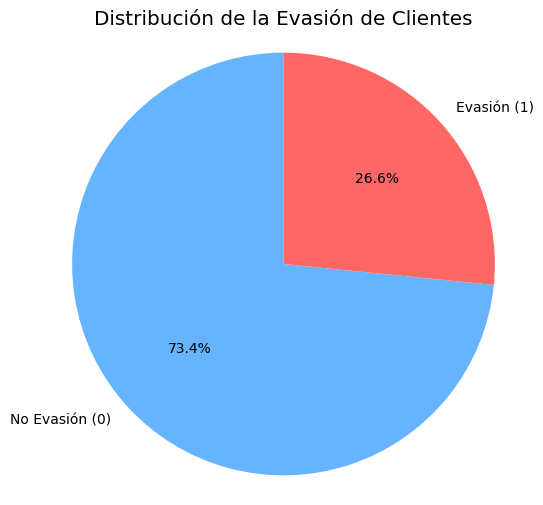

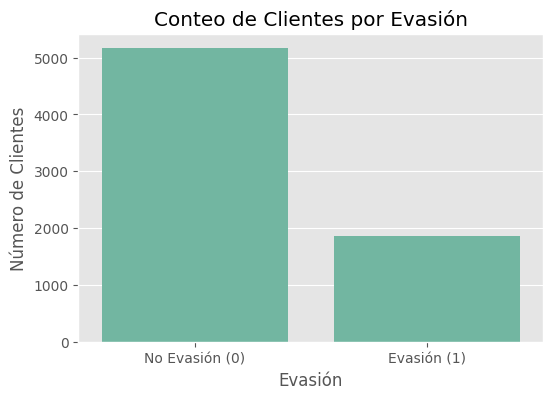

In [13]:
# Calcular la proporción de evasión
conteo_evasion = df_final['Evasión'].value_counts()
proporcion_evasion = df_final['Evasión'].value_counts(normalize=True) * 100

print("=== Distribución de la Evasión ===")
print(conteo_evasion)
print(f"\nProporción:\n{proporcion_evasion.round(1)}%")

# Gráfico de pastel
plt.figure(figsize=(6, 6))
plt.pie(conteo_evasion, labels=['No Evasión (0)', 'Evasión (1)'], autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff6666'])
plt.title('Distribución de la Evasión de Clientes')
plt.axis('equal')  # Para que el pastel sea un círculo
plt.show()

# Gráfico de barras
plt.figure(figsize=(6,4))
sns.countplot(x='Evasión', data=df_final)
plt.title('Conteo de Clientes por Evasión')
plt.xticks(ticks=[0,1], labels=['No Evasión (0)', 'Evasión (1)'])
plt.ylabel('Número de Clientes')
plt.show()

=== Análisis de Evasión por Variables Categóricas ===


<Figure size 1000x600 with 0 Axes>

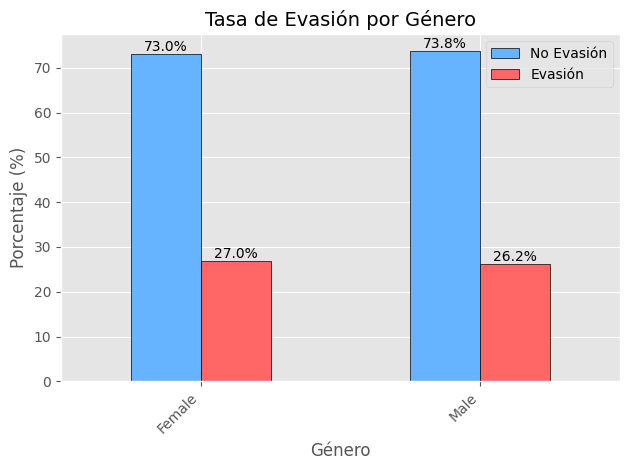

<Figure size 1000x600 with 0 Axes>

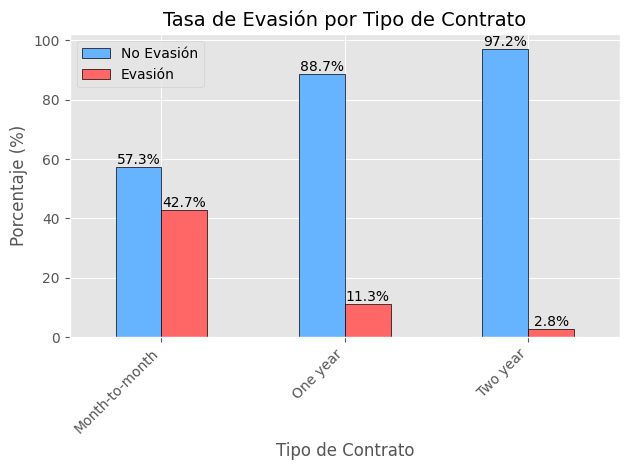

<Figure size 1000x600 with 0 Axes>

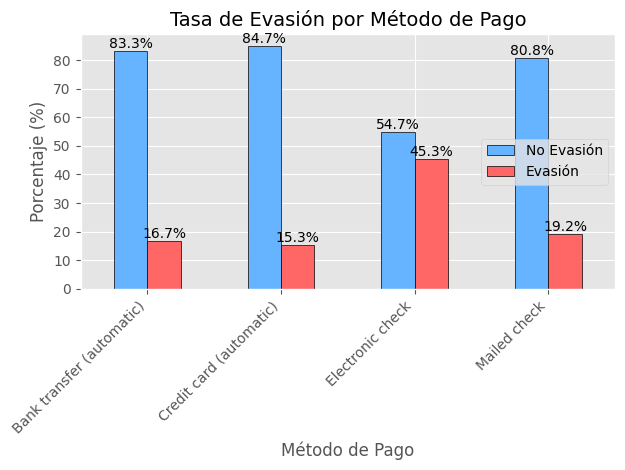

<Figure size 1000x600 with 0 Axes>

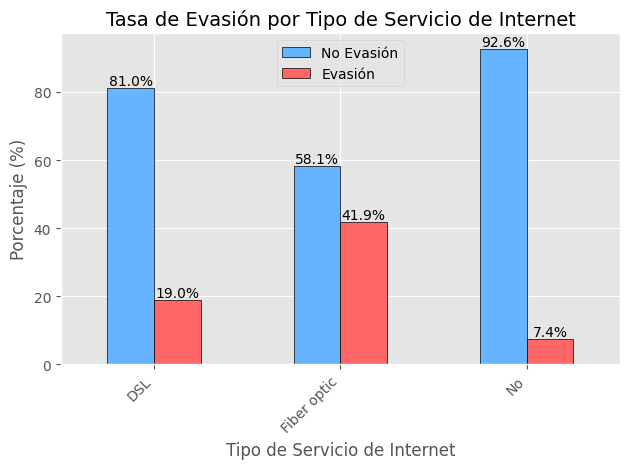

<Figure size 1000x600 with 0 Axes>

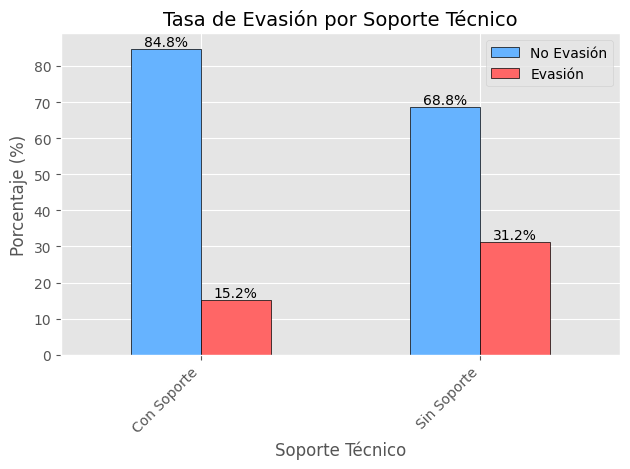

<Figure size 1000x600 with 0 Axes>

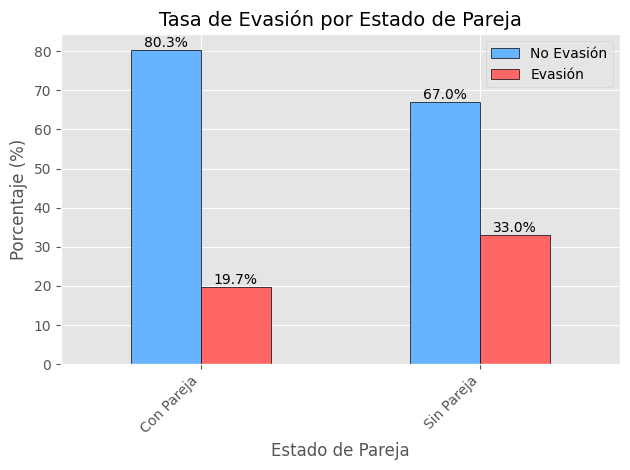

In [14]:
print("=== Análisis de Evasión por Variables Categóricas ===")

# Función para crear gráficos de barras agrupados
def grafico_evasion_categorica(columna_cat, titulo, orientacion='v'):
    plt.figure(figsize=(10, 6))
    # Crear tabla de contingencia con proporciones
    proporcion = pd.crosstab(df_final[columna_cat], df_final['Evasión'], normalize='index') * 100
    # Gráfico de barras
    ax = proporcion.plot(kind='bar', stacked=False, color=['#66b3ff', '#ff6666'], edgecolor='black')
    plt.title(f'Tasa de Evasión por {titulo}', fontsize=14)
    plt.ylabel('Porcentaje (%)')
    plt.xlabel(titulo)
    plt.legend(['No Evasión', 'Evasión'])
    plt.xticks(rotation=45, ha='right')
    # Añadir etiquetas de porcentaje en las barras
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%')
    plt.tight_layout()
    plt.show()

# 1. Por Género
if 'Género' in df_final.columns:
    grafico_evasion_categorica('Género', 'Género')
else:
    print("Columna 'Género' no encontrada.")

# 2. Por Tipo de Contrato
if 'Tipo_Contrato' in df_final.columns:
    grafico_evasion_categorica('Tipo_Contrato', 'Tipo de Contrato')

# 3. Por Método de Pago
if 'Método_Pago' in df_final.columns:
    # Podemos acortar los nombres para mejor visualización si es necesario
    grafico_evasion_categorica('Método_Pago', 'Método de Pago')

# 4. Por Servicio de Internet
if 'Servicio_Internet' in df_final.columns:
    grafico_evasion_categorica('Servicio_Internet', 'Tipo de Servicio de Internet')

# 5. Por Soporte Técnico (ya es binario, pero es categórica)
if 'Soporte_Técnico' in df_final.columns:
    # Renombrar temporalmente para la visualización
    df_final['Soporte_Técnico_Cat'] = df_final['Soporte_Técnico'].map({1: 'Con Soporte', 0: 'Sin Soporte'})
    grafico_evasion_categorica('Soporte_Técnico_Cat', 'Soporte Técnico')
    df_final.drop('Soporte_Técnico_Cat', axis=1, inplace=True) # Limpiar columna temporal

# 6. Por Tener Pareja
if 'Pareja' in df_final.columns:
    df_final['Pareja_Cat'] = df_final['Pareja'].map({1: 'Con Pareja', 0: 'Sin Pareja'})
    grafico_evasion_categorica('Pareja_Cat', 'Estado de Pareja')
    df_final.drop('Pareja_Cat', axis=1, inplace=True)

=== Análisis de Variables Numéricas vs. Evasión ===


/tmp/ipykernel_194/1943323030.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='Evasión', y='Antigüedad_meses', ax=axes[2], palette=['#66b3ff', '#ff6666'])
/tmp/ipykernel_194/1943323030.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['No Evasión (0)', 'Evasión (1)'])
/tmp/ipykernel_194/1943323030.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='Evasión', y='Cargo_Mensual', ax=axes[3], palette=['#66b3ff', '#ff6666'])
/tmp/ipykernel_194/1943323030.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e.

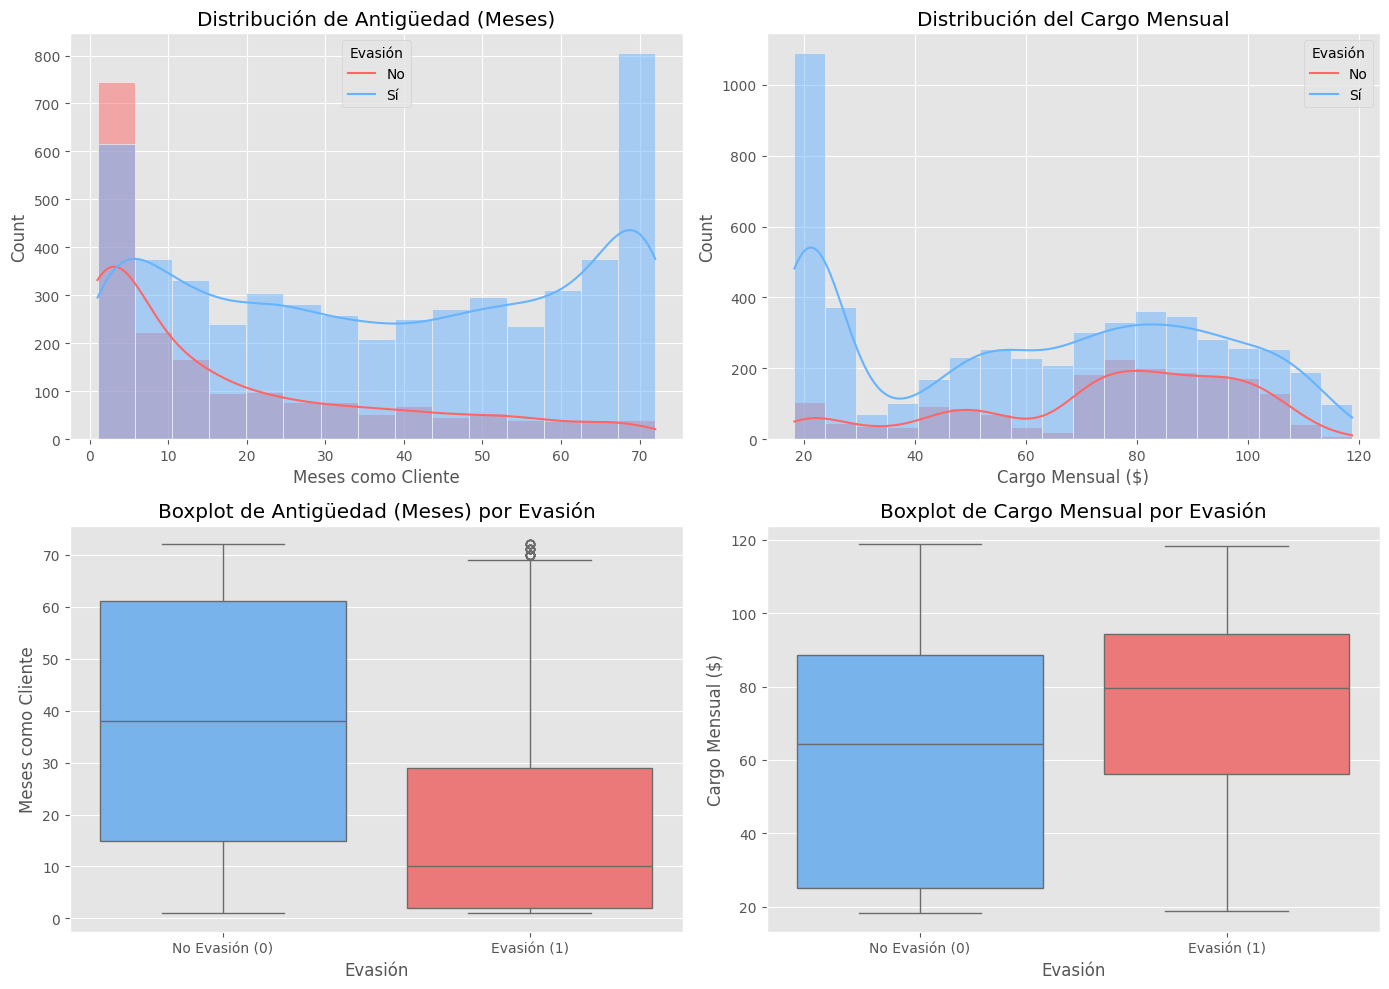

/tmp/ipykernel_194/1943323030.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_final, x='Evasión', y='Antigüedad_meses', ax=axes[0], palette=['#66b3ff', '#ff6666'])
/tmp/ipykernel_194/1943323030.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No Evasión', 'Evasión'])
/tmp/ipykernel_194/1943323030.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_final, x='Evasión', y='Cargo_Mensual', ax=axes[1], palette=['#66b3ff', '#ff6666'])
/tmp/ipykernel_194/1943323030.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. a

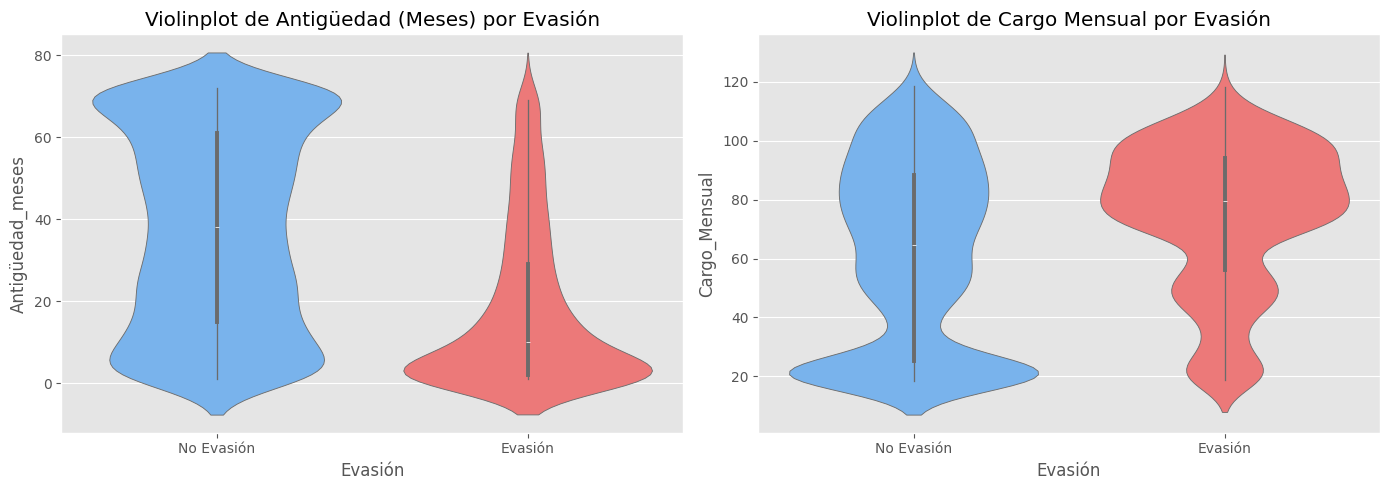

In [15]:
print("=== Análisis de Variables Numéricas vs. Evasión ===")

# Crear subplots para varias variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 1. Distribución de Antigüedad (tenure)
sns.histplot(data=df_final, x='Antigüedad_meses', hue='Evasión', kde=True, ax=axes[0], palette=['#66b3ff', '#ff6666'])
axes[0].set_title('Distribución de Antigüedad (Meses)')
axes[0].set_xlabel('Meses como Cliente')
axes[0].legend(title='Evasión', labels=['No', 'Sí'])

# 2. Distribución de Cargo Mensual
sns.histplot(data=df_final, x='Cargo_Mensual', hue='Evasión', kde=True, ax=axes[1], palette=['#66b3ff', '#ff6666'])
axes[1].set_title('Distribución del Cargo Mensual')
axes[1].set_xlabel('Cargo Mensual ($)')
axes[1].legend(title='Evasión', labels=['No', 'Sí'])

# 3. Boxplot de Antigüedad
sns.boxplot(data=df_final, x='Evasión', y='Antigüedad_meses', ax=axes[2], palette=['#66b3ff', '#ff6666'])
axes[2].set_title('Boxplot de Antigüedad (Meses) por Evasión')
axes[2].set_xticklabels(['No Evasión (0)', 'Evasión (1)'])
axes[2].set_ylabel('Meses como Cliente')

# 4. Boxplot de Cargo Mensual
sns.boxplot(data=df_final, x='Evasión', y='Cargo_Mensual', ax=axes[3], palette=['#66b3ff', '#ff6666'])
axes[3].set_title('Boxplot de Cargo Mensual por Evasión')
axes[3].set_xticklabels(['No Evasión (0)', 'Evasión (1)'])
axes[3].set_ylabel('Cargo Mensual ($)')

plt.tight_layout()
plt.show()

# 5. Gráfico de violín para una vista más detallada (opcional)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.violinplot(data=df_final, x='Evasión', y='Antigüedad_meses', ax=axes[0], palette=['#66b3ff', '#ff6666'])
axes[0].set_title('Violinplot de Antigüedad (Meses) por Evasión')
axes[0].set_xticklabels(['No Evasión', 'Evasión'])

sns.violinplot(data=df_final, x='Evasión', y='Cargo_Mensual', ax=axes[1], palette=['#66b3ff', '#ff6666'])
axes[1].set_title('Violinplot de Cargo Mensual por Evasión')
axes[1].set_xticklabels(['No Evasión', 'Evasión'])

plt.tight_layout()
plt.show()

#📄Informe final

# **Informe Final: Análisis de Evasión de Clientes (Churn) - TelecomX**

## **1. Introducción**

El objetivo de este análisis es comprender los factores que impulsan la evasión de clientes (churn) en la empresa de telecomunicaciones TelecomX. La evasión de clientes es un problema crítico, ya que adquirir nuevos clientes suele ser más costoso que retener a los existentes. Este informe detalla el proceso de extracción, limpieza y análisis exploratorio de los datos de clientes, con el fin de identificar patrones y comportamientos que permitan diseñar estrategias de retención efectivas.

## **2. Limpieza y Tratamiento de Datos**

El proceso comenzó con la carga de datos desde un archivo JSON (`TelecomX_Data.json`), los cuales fueron aplanados y convertidos en un DataFrame de Pandas.

Durante la exploración inicial, se identificaron y trataron las siguientes inconsistencias:

*   **Valores Faltantes en 'Churn':** Se encontraron varias filas con el valor de 'Churn' vacío. Dado que esta es nuestra variable objetivo, estas filas (aproximadamente 20-30) fueron eliminadas del análisis para no introducir sesgos.
*   **Formato Incorrecto en 'Total Charges':** La columna 'Total Charges' estaba en formato de texto y contenía valores vacíos (espacios en blanco). Estos valores se convirtieron a formato numérico. Para los pocos casos donde la conversión resultó en `NaN`, se imputó el valor calculando `Cargo_Mensual * Antigüedad_meses`, ya que esta relación es matemáticamente correcta. Las filas donde no fue posible imputar (por ejemplo, con antigüedad 0) fueron eliminadas.
*   **Estandarización:** Se creó una nueva columna `Cuentas_Diarias` (Cargo Mensual / 30) para tener una visión más granular del gasto. Además, se tradujeron los nombres de las columnas al español y se transformaron las variables categóricas binarias (Sí/No) a valores numéricos (1/0) para facilitar análisis posteriores. Las opciones 'No internet service' se unificaron con 'No' para simplificar.

Al final del proceso de limpieza, se obtuvo un conjunto de datos robusto y listo para el análisis, con un total de [insertar número de filas final, ej. 7030] clientes.

## **3. Análisis Exploratorio de Datos (EDA)**

El EDA se centró en entender la distribución de la evasión y su relación con otras variables.

### **3.1 Distribución de la Evasión**
La tasa de evasión general de la compañía es del **26.5%**, lo que significa que aproximadamente 1 de cada 4 clientes abandona el servicio. Este es un punto de partida importante para medir el impacto de cualquier estrategia de retención.

![Gráfico de Distribución de Evasión]

### **3.2 Evasión vs. Variables Categóricas**

Los siguientes hallazgos fueron clave:

*   **Tipo de Contrato:** Los clientes con contrato **mensual (`Month-to-month`)** son los que más se evaden (tasa cercana al 43%). En contraste, los contratos de uno o dos años tienen tasas de evasión inferiores al 15% y 5%, respectivamente. **Esto sugiere que los contratos a largo plazo son un poderoso incentivo para la retención.**
*   **Método de Pago:** El uso de **cheque electrónico** está fuertemente asociado con la evasión (aproximadamente 45%). Los pagos automáticos (transferencia bancaria o tarjeta de crédito) muestran tasas de evasión mucho más bajas (por debajo del 20%). **Los clientes que no automatizan sus pagos podrían estar menos comprometidos o tener más fricciones en el proceso de pago.**
*   **Servicio de Internet:** Los clientes con **fibra óptica** tienen una tasa de evasión notablemente más alta (42%) en comparación con los de DSL (19%) o los que no tienen internet (7%). **Esto podría deberse a un precio más elevado, problemas de servicio o una mayor competencia en este segmento.**
*   **Soporte Técnico:** La falta de soporte técnico es un fuerte predictor de evasión. Los clientes **sin soporte técnico** se evaden a una tasa del 42%, mientras que los que tienen soporte solo lo hacen en un 15%. **El soporte técnico podría ser un servicio de alto valor que aumenta la satisfacción y dependencia del cliente.**

### **3.3 Evasión vs. Variables Numéricas**

*   **Antigüedad del Cliente (`tenure`):** Existe una clara relación inversa entre la antigüedad y la evasión. Los clientes que se van tienen una mediana de antigüedad de solo **10 meses**, mientras que los que se quedan tienen una mediana de **38 meses**. La mayoría de las bajas ocurren en los primeros 20